,total_words,total_tokens,avg_tokens_per_word,%_1_token,%_2_tokens,%_3+_tokens
English,271.0,389.0,1.44,62.0,23.2,14.8
French,308.0,650.0,2.11,47.1,19.8,33.1
Polish,237.0,810.0,3.42,22.8,17.7,59.5


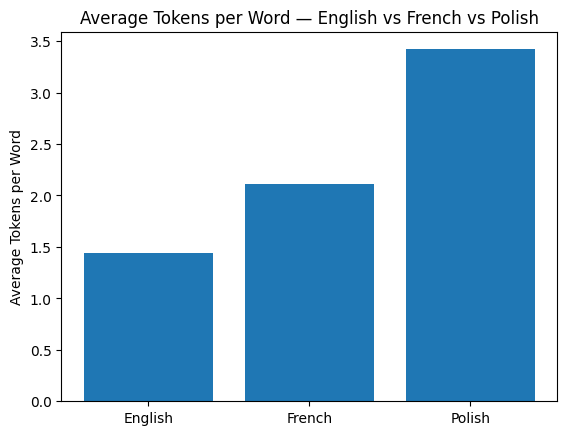

In [8]:
english_text = """
Ottawa is the capital city of Canada. It is located in the southern portion of the province of Ontario,
at the confluence of the Ottawa River and the Rideau River. Ottawa borders Gatineau, Quebec, and forms
the core of the Ottawa–Gatineau census metropolitan area (CMA) and the National Capital Region (NCR).
As of 2021, Ottawa had a city population of 1,017,449 and a metropolitan population of 1,488,307,
making it the fourth-largest city and fourth-largest metropolitan area in Canada.

Ottawa is the political centre of Canada and the headquarters of the federal government. The city houses
numerous foreign embassies, key buildings, organizations, and institutions of Canada's government;
these include the Parliament of Canada, the Supreme Court, the residence of Canada's viceroy, and the
Office of the Prime Minister.

Founded in 1826 as Bytown, and incorporated as Ottawa in 1855, its original boundaries were expanded
through numerous annexations and were ultimately replaced by a new city incorporation and amalgamation in 2001.
The municipal government of Ottawa is established and governed by the City of Ottawa Act of the Government
of Ontario. It has an elected city council across 24 wards and a mayor elected city-wide, each elected
using the first-past-the-post voting system.

Ottawa has the highest proportion of university-educated residents among Canadian cities and is home to
several colleges, universities, and research and cultural institutions, including the University of Ottawa,
Carleton University, Algonquin College, Collège La Cité, the National Arts Centre, and the National Gallery of Canada,
as well as numerous national museums, monuments, and historic sites. It is one of the most visited cities in Canada,
with over 11 million visitors annually.
"""
#I choose this text, because it’s factual, neutral, and encyclopedic, so ideal for analyzing
#how tokenization handles named entities, numbers, and punctuation in three languages

#Polish text about Ottawa
polish_text = """
Ottawa jest stolicą Kanady. Miasto znajduje się w południowej części prowincji Ontario,
u zbiegu rzek Ottawa i Rideau. Ottawa graniczy z Gatineau w Quebecu i stanowi rdzeń obszaru metropolitalnego
Ottawa–Gatineau (CMA) oraz Narodowego Regionu Stołecznego (NCR). Według danych z 2021 roku Ottawa miała
populację miejską wynoszącą 1 017 449 mieszkańców oraz populację metropolitalną wynoszącą 1 488 307,
co czyni ją czwartym co do wielkości miastem i obszarem metropolitalnym w Kanadzie.

Ottawa jest politycznym centrum Kanady i siedzibą rządu federalnego. W mieście znajduje się wiele
zagranicznych ambasad, kluczowych budynków, organizacji i instytucji rządowych Kanady, w tym Parlament Kanady,
Sąd Najwyższy, rezydencja gubernatora generalnego oraz Biuro Premiera.

Miasto zostało założone w 1826 roku jako Bytown, a w 1855 roku zostało włączone jako Ottawa.
Jego pierwotne granice były wielokrotnie rozszerzane poprzez liczne aneksje, aż w 2001 roku powstało
nowe miasto w wyniku inkorporacji i połączenia. Władze miejskie Ottawy działają na podstawie ustawy
City of Ottawa Act uchwalonej przez rząd prowincji Ontario. Rada miejska składa się z 24 okręgów
i burmistrza wybieranego w całym mieście, w wyborach według systemu większościowego.

Ottawa ma najwyższy odsetek mieszkańców z wykształceniem wyższym wśród kanadyjskich miast i jest siedzibą
kilku uczelni, instytucji badawczych i kulturalnych, w tym Uniwersytetu Ottawskiego, Uniwersytetu Carletona,
Algonquin College, Collège La Cité, National Arts Centre i National Gallery of Canada,
a także licznych muzeów narodowych, pomników i zabytków. Jest jednym z najczęściej odwiedzanych miast
w Kanadzie, z ponad 11 milionami turystów rocznie.
"""
#French text about Ottawa
french_text = """
Ottawa[a] est la capitale du Canada. Elle est située dans la partie sud de la province de l’Ontario,
à la confluence de la rivière des Outaouais et de la rivière Rideau. Ottawa borde Gatineau, au Québec,
et forme le cœur de la région métropolitaine d’Ottawa–Gatineau (RMR) ainsi que de la Région de la
capitale nationale (RCN). En 2021, Ottawa comptait une population municipale de 1 017 449 habitants
et une population métropolitaine de 1 488 307, ce qui en fait la quatrième plus grande ville et la
quatrième plus grande région métropolitaine du Canada.

Ottawa est le centre politique du Canada et le siège du gouvernement fédéral. La ville abrite de
nombreuses ambassades étrangères, des bâtiments clés, des organisations et des institutions
gouvernementales canadiennes, notamment le Parlement du Canada, la Cour suprême, la résidence du
vice-roi du Canada et le Bureau du premier ministre.

Fondée en 1826 sous le nom de Bytown et incorporée sous le nom d’Ottawa en 1855, ses limites originales
ont été élargies par de nombreuses annexions et ont finalement été remplacées par une nouvelle
incorporation municipale et une fusion en 2001. Le gouvernement municipal d’Ottawa est établi et régi
par la Loi sur la ville d’Ottawa du gouvernement de l’Ontario. Il comprend un conseil municipal élu
dans 24 quartiers et un maire élu à l’échelle de la ville, chacun au scrutin uninominal à un tour.

Ottawa possède la proportion la plus élevée de résidents titulaires d’un diplôme universitaire parmi
les villes canadiennes et abrite plusieurs collèges, universités et institutions culturelles et de
recherche, notamment l’Université d’Ottawa, l’Université Carleton, le Collège Algonquin, le Collège
La Cité, le Centre national des Arts et le Musée des beaux-arts du Canada, ainsi que de nombreux
musées et sites historiques nationaux. C’est l’une des villes les plus visitées du Canada, avec plus
de 11 millions de visiteurs par an.
"""
from transformers import GPT2Tokenizer
import pandas as pd
import matplotlib.pyplot as plt

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

texts = {
    "English": english_text,
    "French": french_text,
    "Polish": polish_text
}

stats = {}

for lang, text in texts.items():
    tokens = tokenizer.tokenize(text)
    token_count = len(tokens)
    words = text.split()
    word_count = len(words)

    word_token_counts = [len(tokenizer.tokenize(w)) for w in words]
    one_tok = sum(1 for c in word_token_counts if c == 1)
    two_tok = sum(1 for c in word_token_counts if c == 2)
    three_plus = sum(1 for c in word_token_counts if c >= 3)

    stats[lang] = {
        "total_words": word_count,
        "total_tokens": token_count,
        "avg_tokens_per_word": round(token_count / word_count, 2),
        "%_1_token": round(one_tok / word_count * 100, 1),
        "%_2_tokens": round(two_tok / word_count * 100, 1),
        "%_3+_tokens": round(three_plus / word_count * 100, 1)
    }

df = pd.DataFrame(stats).T
display(df)

#Chart
plt.bar(df.index, df["avg_tokens_per_word"])
plt.title("Average Tokens per Word — English vs French vs Polish")
plt.ylabel("Average Tokens per Word")
plt.show()

#English is the most token-efficient, since many English words are short and match GPT’s subword vocabulary directly.
#French words often contain prefixes and suffixes, producing 2-token splits.
#Polish is the most “expensive” because its inflected endings and longer word forms create multiple subword pieces per word.
#GPT’s tokenizer is optimized for English, so non-Latin or morphologically rich languages yield more tokens per word.

#Conclusion
#Languages with complex morphology or diacritics (like Polish) generate more tokens and thus cost more in API usage. English remains the most compact for LLM tokenization.

In [7]:
from IPython.display import display
import pandas as pd

#5 words for each language
example_words = {
    "English": ["Ottawa", "federal", "government", "university", "population"],
    "French": ["capitale", "gouvernement", "université", "résidents", "culturelles"],
    "Polish": ["rządu", "mieszkańców", "najczęściej", "odpowiedzialność", "metropolitalnego"]
}

#list for table
rows = []

for lang, words in example_words.items():
    for w in words:
        tokens = tokenizer.tokenize(w)  # GPT-токенизация
        rows.append({
            "Language": lang,
            "Word": w,
            "Tokens": tokens,
            "Num_Tokens": len(tokens)
        })

df_examples = pd.DataFrame(rows)

display(df_examples)

#Short analysis
#English: mostly 1 or two tokens for word
#French: 3 tokens for most of the words
#Polish: a big amount of tokens because of more complex morfology and etc.


,Language,Word,Tokens,Num_Tokens
0,English,Ottawa,"[Ott, awa]",2
1,English,federal,"[f, ederal]",2
2,English,government,[government],1
3,English,university,"[un, iversity]",2
4,English,population,[population],1
5,French,capitale,"[cap, it, ale]",3
6,French,gouvernement,"[g, ou, vern, ement]",4
7,French,université,"[un, ivers, itÃ©]",3
8,French,résidents,"[r, Ã©s, idents]",3
9,French,culturelles,"[culture, ll, es]",3
